In [23]:
from agents.nodes import load_skills_node
from src.agents.nodes.generate_sql_node import generate_sql_node
from utils.sql_tools import WmsSqlTool
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool, QuerySQLCheckerTool, InfoSQLDatabaseTool,ListSQLDatabaseTool
from langchain_google_genai import ChatGoogleGenerativeAI
from src.config import settings

_llm = None

def _getllm() -> ChatGoogleGenerativeAI:
    global _llm

    if _llm is None:
        _llm = ChatGoogleGenerativeAI(
            model=settings.GOOGLE_AI_MODEL,
            api_key=settings.GOOGLE_API_KEY,


        )
    return _llm
tools = WmsSqlTool(query_check_llm=_getllm())

query_tool = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLDatabaseTool))
query_check = next(t for t in tools.get_sql_tools() if isinstance(t, QuerySQLCheckerTool))
list_tables = next(t for t in tools.get_sql_tools() if isinstance(t, ListSQLDatabaseTool))
list_info = next(t for t in tools.get_sql_tools() if isinstance(t, InfoSQLDatabaseTool))

res= list_info.invoke({"table_names": list_tables.invoke("")})


In [ ]:
res

In [ ]:
tool = tools.get_sql_tools()

next(t for t in tool if isinstance(t, QuerySQLDatabaseTool))

In [ ]:
from pprint import pprint
check_sql = "select * from inventory wher limit 10"
checked_sql = query_check.invoke({"query": check_sql})
pprint(checked_sql)


In [25]:
from data.state import WMState
from agents.nodes.router import router_node

state = WMState(
    ticket_number= "INC12345",
    description= "how to slot sku003 and how much",
    user_id= "rahul"
)

router = router_node(state)

router


{'intent': 'diagnose', 'domain': 'inventory'}

In [21]:
from agents.nodes.sql_query import sql_query
from data.state import WMState
state = WMState(
    ticket_number= "INC12345",
    description= "whats my receivng workload",
    user_id= "rahul"
)

router = sql_query(state)

from rich.console import Console
from rich.markdown import Markdown
console = Console()
content = router["response"]["messages"][-1].content[0]['text']
console.print(Markdown(content))


ModuleNotFoundError: No module named 'agents.nodes.sql_query'

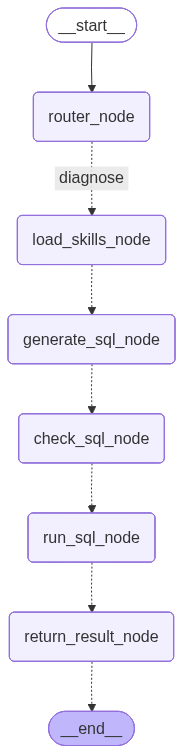

In [26]:
from langgraph.graph import StateGraph, START, END
from src.data.state import WMState
from IPython.display import display, Image
from src.agents.nodes.router import router_node
from src.agents.nodes.load_skills_node import load_skills_node
from src.agents.nodes.generate_sql_node import generate_sql_node
from src.agents.nodes.check_sql_node import check_sql_node
from src.agents.nodes.run_sql_node import run_sql_node
from src.agents.nodes.return_result_node import return_result_node
from src.agents.edges.router_intent_edge import router_intent_edge
from langgraph.cache.memory import InMemoryCache
from dotenv import load_dotenv
load_dotenv()
builder = StateGraph(WMState)


builder.add_node("router_node", router_node)
builder.add_node("load_skills_node", load_skills_node)
builder.add_node("generate_sql_node", generate_sql_node)
builder.add_node("check_sql_node", check_sql_node)
builder.add_node("run_sql_node", run_sql_node)
builder.add_node("return_result_node", return_result_node)

builder.add_edge(START, "router_node")
builder.add_conditional_edges(
    "router_node",
    router_intent_edge,
    {
        "lookup":"load_skills_node",
        "diagnose": "load_skills_node"
    }
)

graph = builder.compile(cache=InMemoryCache())

display(Image(graph.get_graph().draw_mermaid_png()))


In [27]:
result = graph.invoke(
    {
        "ticket_number": "INC12345",
        "description": "whats my inventory level overall invlusing inbound and outbound?",
        "user_id": "rahul",
    }
)

from rich.console import Console
from rich.markdown import Markdown
console = Console()
content = result["final_response"]
console.print(Markdown(content))

skill domain used: inventory Result: [(255170,)]

In [ ]:
from typing import Literal

from langchain_core.messages import HumanMessage
from langgraph.types import Command

from data.state import WMState
from models.model_loader import get_google_llm

get_google_llm().invoke([HumanMessage(content="Hello")]).content[0]["text"].strip()

In [4]:
import asyncio

from agents.nodes.supervisor_node import SupervisorNode
from data.state import WMState

message = (
   "picking is low and uph is low but invenotry is high why and also inbound has no work"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)


node = SupervisorNode()
response = await node(state)
print(response)


Command(update={'active_task_id': 'f51609c8-5b75-484e-b247-bc76b21c66a0', 'loop_count': 1, 'messages': [AIMessage(content='Supervisor delegated task inventory_agent to f51609c8-5b75-484e-b247-bc76b21c66a0', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), AIMessage(content='Supervisor delegated task outbound_agent to f51609c8-5b75-484e-b247-bc76b21c66a0', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]), AIMessage(content='Supervisor delegated task inbound_agent to f51609c8-5b75-484e-b247-bc76b21c66a0', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}, goto=[Send(node='inventory_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='inventory_agent', task='Analyze inventory levels and location accuracy to identify why high inventory levels are not translating into higher picking efficiency.')), Send(node='outbound_agent', arg=WorkerInput(task_id='f51609c8-5

In [11]:
for data in response.goto:
    print(data)
    print("="*90)


Send(node='inventory_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='inventory_agent', task='Analyze inventory levels and location accuracy to identify why high inventory levels are not translating into higher picking efficiency.'))
Send(node='outbound_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='outbound_agent', task='Evaluate picking processes, warehouse layout, and staff performance metrics to determine the cause of low UPH.'))
Send(node='inbound_agent', arg=WorkerInput(task_id='f51609c8-5b75-484e-b247-bc76b21c66a0', agent_name='inbound_agent', task='Review inbound scheduling and receiving data to confirm the lack of current inbound work and potential impact on warehouse flow.'))


In [1]:
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from data.state import WMState, WorkerInput
from langgraph.types import Send

AGENTS = {
    "inbound_agent": inbound_agent_node,
    # "outbound_agent": outbound_agent_node,
    # "inventory_agent": inventory_agent_node,
}

message = (
    "why is sku003 low in inbound"
)

state = WMState(
    ticket_number="INC12345",
    description=message,
    user_id="rahul",
)

supervisor = SupervisorNode()

# Run supervisor
cmd = await supervisor(state)
print("Supervisor returned:")
print(cmd)


Supervisor returned:
Command(update={'active_task_id': 'ceb73c8d-e099-442d-8692-4410efab9449', 'loop_count': 1, 'messages': [AIMessage(content='Supervisor delegated task inbound_agent to ceb73c8d-e099-442d-8692-4410efab9449', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]}, goto=[Send(node='inbound_agent', arg=WorkerInput(task_id='ceb73c8d-e099-442d-8692-4410efab9449', agent_name='inbound_agent', task='Investigate the inbound flow for SKU003, specifically checking for missing or delayed ASNs, PO backlog, and putaway delays affecting the availability of this specific SKU.'))])


In [3]:
from agents.nodes.supervisor_node import SupervisorNode
from agents.nodes.inbound_agent_node import inbound_agent_node
from data.state import WMState, WorkerInput

inbound_agent_node(
    WorkerInput(task="what the total inventory in inbound", task_id="3434", agent_name="inbound_agent"))

{'task_id': '3434',
 'agent_name': 'inbound_agent',
 'messages': [{'type': 'text',
   'text': 'There are currently **80,884** units of inventory left to process in inbound.',
   'extras': {'signature': 'EjQKMgG+Pvb7TXve5AiDIb94uy+dYmRoypNK3HkBakdLUGiNfjeSqbbDg2lrhhtf9/ECngyW'}}]}